In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)


pandas: 3.0.3
matplotlib: 3.11.0
seaborn: 0.13.2


In [2]:
df = pd.read_excel("online_retail_II.xlsx")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.shape

(525461, 8)

In [4]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [7]:
df.isnull().sum().sort_values(ascending=False)

Customer ID    107927
Description      2928
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(6865)

In [9]:
df["Quantity"].describe()

count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64

In [10]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities:", (df["Quantity"] == 0).sum())

Negative quantities: 12326
Zero quantities: 0


In [11]:
df["Price"].describe()

count    525461.000000
mean          4.688834
std         146.126914
min      -53594.360000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

In [12]:
print("Negative prices:", (df["Price"] < 0).sum())
print("Zero prices:", (df["Price"] == 0).sum())

Negative prices: 3
Zero prices: 3687


In [13]:
df[df["Price"] == 0][["Invoice", "StockCode", "Description", "Quantity", "Customer ID", "Country"]].head(10)

,Invoice,StockCode,Description,Quantity,Customer ID,Country
263,489464,21733,85123a mixed,-96,NaN,United Kingdom
283,489463,71477,short,-240,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,NaN,United Kingdom
470,489521,21646,NaN,-50,NaN,United Kingdom
3114,489655,20683,NaN,-44,NaN,United Kingdom
3161,489659,21350,NaN,230,NaN,United Kingdom
3162,489660,35956,lost,-1043,NaN,United Kingdom
3168,489663,35605A,damages,-117,NaN,United Kingdom
3731,489781,84292,NaN,17,NaN,United Kingdom
4296,489806,18010,NaN,-770,NaN,United Kingdom


In [14]:
df[df["Price"] < 0][["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,-38925.87,NaN,United Kingdom


In [15]:
df_clean = df.copy()

print("Original rows:", len(df_clean))

# Remove transactions without a Customer ID
df_clean = df_clean.dropna(subset=["Customer ID"])

print("After removing missing Customer IDs:", len(df_clean))

Original rows: 525461
After removing missing Customer IDs: 417534


In [16]:
print("Duplicate rows before removal:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicate rows after removal:", df_clean.duplicated().sum())
print("Rows remaining:", len(df_clean))

Duplicate rows before removal: 6771
Duplicate rows after removal: 0
Rows remaining: 410763


In [17]:
print("Negative quantities:", (df_clean["Quantity"] < 0).sum())
print("Zero quantities:", (df_clean["Quantity"] == 0).sum())

Negative quantities: 9816
Zero quantities: 0


In [18]:
df_clean = df_clean[df_clean["Quantity"] > 0]

print("Negative quantities after removal:", (df_clean["Quantity"] < 0).sum())
print("Rows remaining:", len(df_clean))

Negative quantities after removal: 0
Rows remaining: 400947


In [19]:
print("Zero prices:", (df_clean["Price"] == 0).sum())
print("Negative prices:", (df_clean["Price"] < 0).sum())

Zero prices: 31
Negative prices: 0


In [20]:
df_clean = df_clean[df_clean["Price"] > 0]

print("Zero prices after removal:", (df_clean["Price"] == 0).sum())
print("Negative prices after removal:", (df_clean["Price"] < 0).sum())
print("Rows remaining:", len(df_clean))

Zero prices after removal: 0
Negative prices after removal: 0
Rows remaining: 400916


In [21]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


### Observation

The dataset was cleaned to prepare it for customer segmentation analysis. Rows with missing Customer IDs were removed because customer identification is required for segmentation. Duplicate transactions were also removed to prevent repeated records from affecting the analysis. Negative quantity transactions, which represent returns or cancellations, were excluded, while transactions with zero or negative prices were removed because they do not represent normal paid purchases.

After cleaning, the dataset contains 400,916 valid transaction records with no missing values, duplicates, negative quantities, or invalid prices. The cleaned dataset is now suitable for customer-level analysis and clustering.

In [22]:
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["Price"]

print(df_clean[["Quantity", "Price", "TotalAmount"]].head())

   Quantity  Price  TotalAmount
0        12   6.95         83.4
1        12   6.75         81.0
2        12   6.75         81.0
3        48   2.10        100.8
4        24   1.25         30.0


In [23]:
df_clean["TotalAmount"].describe()

count    400916.000000
mean         21.945330
std          77.758075
min           0.001000
25%           5.000000
50%          12.500000
75%          19.500000
max       15818.400000
Name: TotalAmount, dtype: float64

In [24]:
customer_summary = df_clean.groupby("Customer ID").agg(
    AveragePurchaseValue=("TotalAmount", "mean"),
    PurchaseFrequency=("Invoice", "nunique"),
    CustomerLifetimeValue=("TotalAmount", "sum")
).reset_index()

print(customer_summary.head())
print("\nNumber of customers:", len(customer_summary))

   Customer ID  AveragePurchaseValue  PurchaseFrequency  CustomerLifetimeValue
0      12346.0             11.298788                 11                 372.86
1      12347.0             18.638310                  2                1323.32
2      12348.0             11.108000                  1                 222.16
3      12349.0             26.187647                  3                2671.14
4      12351.0             14.330000                  1                 300.93

Number of customers: 4312


In [25]:
customer_summary[
    ["AveragePurchaseValue", "PurchaseFrequency", "CustomerLifetimeValue"]
].describe()

,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue
count,4312.000000,4312.000000,4312.000000
mean,37.009327,4.455705,2040.406712
std,217.715476,8.170213,8911.755977
min,1.993684,1.000000,2.950000
25%,11.193531,1.000000,307.187500
50%,17.361560,2.000000,701.615000
75%,24.839503,5.000000,1714.932500
max,10953.500000,205.000000,349164.350000


### Observation
The customer-level analysis shows that the dataset contains 4,312 unique customers. The average purchase value was 37.01, while the median was 17.36, indicating that most customers made relatively smaller purchases, with some customers having much higher transaction values. Customers made an average of 4.46 purchases, with a median of 2 purchases. The average Customer Lifetime Value was 2,040.41, compared with a median of 701.62, showing that a smaller number of high-value customers contribute substantially to the overall customer value.
These differences between the mean and median suggest that customer purchasing behaviour is skewed, with some customers making substantially more purchases or spending much more than others. This variation makes the dataset suitable for customer segmentation using behavioural features.

In [26]:
print("Earliest transaction date:", df_clean["InvoiceDate"].min())
print("Latest transaction date:", df_clean["InvoiceDate"].max())

Earliest transaction date: 2009-12-01 07:45:00
Latest transaction date: 2010-12-09 20:01:00


In [27]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2010-12-10 20:01:00


In [28]:
rfm = df_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print(rfm.head())
print("\nNumber of customers:", len(rfm))

   Customer ID  Recency  Frequency  Monetary
0      12346.0      165         11    372.86
1      12347.0        3          2   1323.32
2      12348.0       74          1    222.16
3      12349.0       43          3   2671.14
4      12351.0       11          1    300.93

Number of customers: 4312


In [29]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


### Observation
The RFM analysis provides three key behavioural features for customer segmentation: Recency, Frequency, and Monetary. The average customer had a Recency of approximately 91 days, made about 4.46 purchases, and spent approximately 2,040.41 in total. The median values were 53 days for Recency, 2 purchases for Frequency, and 701.62 for Monetary.
The large differences between the mean and median values, particularly for Frequency and Monetary, indicate that customer purchasing behaviour varies considerably, with some customers making many more purchases and spending substantially more than others. Therefore, Recency, Frequency, and Monetary will be used as the three behavioural features for K-Means clustering.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

print("Scaled data shape:", rfm_scaled.shape)
print("\nFirst 5 scaled rows:")
print(rfm_scaled[:5])

Scaled data shape: (4312, 3)

First 5 scaled rows:
[[ 0.76229851  0.80108727 -0.18713934]
 [-0.91040156 -0.3006029  -0.08047459]
 [-0.17730462 -0.42301292 -0.20405155]
 [-0.4973892  -0.17819288  0.07078363]
 [-0.82779909 -0.42301292 -0.19521163]]


In [31]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(f"K={k}: {value:.2f}")

Inertia values:
K=2: 8728.91
K=3: 5160.29
K=4: 3587.35
K=5: 2740.12
K=6: 2236.06
K=7: 1820.11
K=8: 1560.10
K=9: 1401.95
K=10: 1251.15


In [37]:
rfm

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,4
1,12347.0,3,2,1323.32,1
2,12348.0,74,1,222.16,1
3,12349.0,43,3,2671.14,1
4,12351.0,11,1,300.93,1
...,...,...,...,...,...
4307,18283.0,18,6,619.37,1
4308,18284.0,67,1,461.68,1
4309,18285.0,296,1,427.00,4
4310,18286.0,112,2,1296.43,1


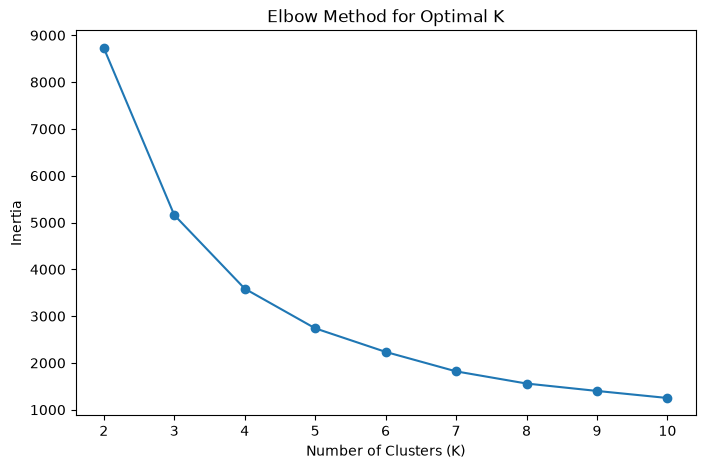

In [32]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)
plt.show()

### Observation

The Elbow Method shows a substantial reduction in inertia as the number of clusters increases from K=2 to K=5. After approximately K=4 to K=5, the reduction in inertia becomes more gradual and the curve begins to flatten. This indicates that adding more clusters beyond this point provides smaller improvements in within-cluster compactness.

The elbow pattern suggests K=5 as a reasonable candidate for the customer segmentation analysis. This choice was further evaluated using Silhouette Analysis to assess the quality and separation of the resulting clusters before finalizing the number of segments.



In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette scores:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: {score:.4f}")

Silhouette scores:
K=2: 0.9314
K=3: 0.5891
K=4: 0.6108
K=5: 0.6140
K=6: 0.5058
K=7: 0.4948
K=8: 0.4949
K=9: 0.4091
K=10: 0.4154


In [35]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())
print("\nNumber of customers in each cluster:")
print(rfm["Cluster"].value_counts().sort_index())

   Customer ID  Recency  Frequency  Monetary  Cluster
0      12346.0      165         11    372.86        4
1      12347.0        3          2   1323.32        1
2      12348.0       74          1    222.16        1
3      12349.0       43          3   2671.14        1
4      12351.0       11          1    300.93        1

Number of customers in each cluster:
Cluster
0     208
1    3053
2      10
3       3
4    1038
Name: count, dtype: int64


### Observation
The RFM features were standardised using StandardScaler so that Recency, Frequency, and Monetary could contribute to the clustering process on a comparable scale. The standardised dataset contains 4,312 customers and 3 features. This step was necessary because the original RFM variables had different numerical ranges, particularly Monetary, which could otherwise have a greater influence on the K-Means distance calculations.
The Elbow Method was then used to evaluate different numbers of clusters by examining K-Means inertia. Inertia decreased as the number of clusters increased, with the largest reductions occurring at the lower values of K. The reduction became progressively smaller as additional clusters were added, suggesting an appropriate solution in the four-to-five-cluster range.
To provide an additional measure of cluster quality, silhouette scores were calculated for K=2 through K=10. Among the multi-cluster solutions from K=3 onward, K=5 produced the highest silhouette score of 0.6140, followed closely by K=4 with 0.6108.
Based on the Elbow Method and silhouette analysis, K=5 was selected for the final K-Means model. The model successfully assigned all 4,312 customers to five clusters. The resulting cluster sizes were uneven: Cluster 0 contained 208 customers, Cluster 1 contained 3,053 customers, Cluster 2 contained 10 customers, Cluster 3 contained 3 customers, and Cluster 4 contained 1,038 customers. The smaller clusters may represent customers with distinctive purchasing patterns, which will be examined further during cluster profiling.

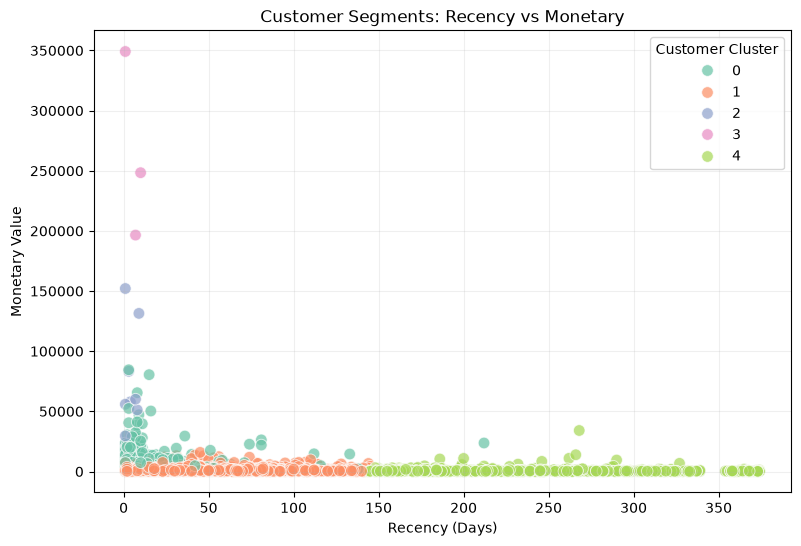

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Cluster")
plt.grid(alpha=0.2)
plt.show()

### Observation

The Recency vs Monetary scatter plot shows clear differences in customer behaviour across the five clusters. Customers in the lower-recency range generally represent more recently active customers, while customers with higher Recency values have gone longer without purchasing.

The plot also shows that the highest Monetary values are concentrated among a small number of customers with very low Recency, corresponding to the exceptionally high-value clusters. In contrast, Cluster 4 is concentrated toward higher Recency values and relatively lower Monetary values, indicating customers who have been inactive for a longer period and have lower overall spending.

The visualization therefore demonstrates how combining Recency and Monetary value helps distinguish highly active, high-value customers from less active and lower-value customers.

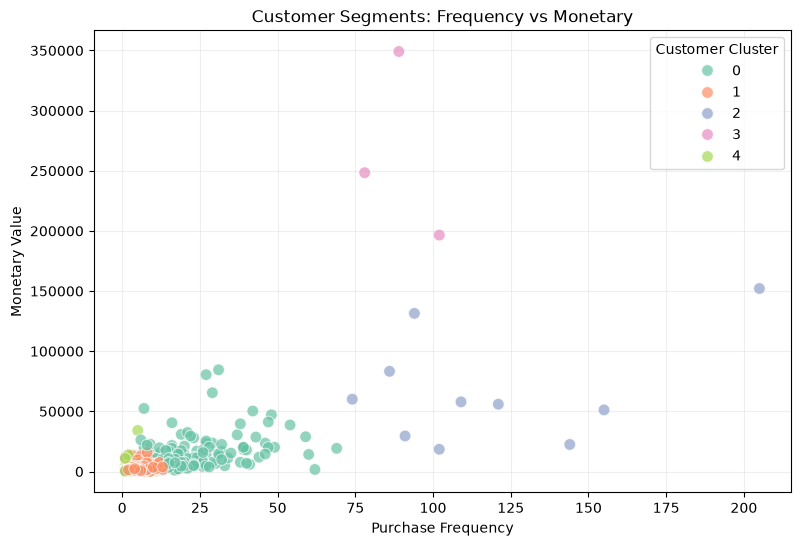

In [39]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Cluster")
plt.grid(alpha=0.2)
plt.show()

### Observation

The Frequency vs Monetary scatter plot shows a clear relationship between purchasing frequency and total customer spending. Most customers are concentrated in the lower-frequency and lower-monetary range, particularly within Cluster 1 and Cluster 4.

The plot also shows a small number of customers with exceptionally high purchase frequencies and monetary values. Clusters 2 and 3 contain these extreme high-value customers, with very high purchase frequencies and substantially greater spending than the other segments. Cluster 0 also represents customers with relatively high frequency and monetary value.

Overall, the visualization demonstrates that customers who purchase more frequently generally contribute higher total monetary value, while the largest customer groups are concentrated at lower purchasing frequencies and spending levels.

In [41]:
cluster_profile = rfm.groupby("Cluster").agg(
    MeanRecency=("Recency", "mean"),
    MeanFrequency=("Frequency", "mean"),
    MeanMonetary=("Monetary", "mean"),
    CustomerCount=("Customer ID", "count")
).reset_index()

print(cluster_profile.round(2))

   Cluster  MeanRecency  MeanFrequency  MeanMonetary  CustomerCount
0        0        16.77          21.76      12210.23            208
1        1        44.70           3.77       1370.06           3053
2        2         3.70         118.10      66250.55             10
3        3         6.00          89.67     264703.53              3
4        4       243.86           1.66        596.43           1038


### Cluster Customer Descriptions

Cluster 0 – High-Value Active Customers: These customers have purchased recently, purchase frequently, and have a high total monetary value. They represent highly engaged and valuable customers.

Cluster 1 – Regular/Developing Customers: This is the largest customer group. These customers show moderate recency, relatively low purchase frequency, and moderate spending. They represent regular customers with potential for increased engagement.

Cluster 2 – Very High-Value Frequent Customers: These customers have purchased very recently, purchase extremely frequently, and have very high monetary value. Although this cluster is small, it represents highly valuable customers.

Cluster 3 – Exceptional-Value Customers: These customers have very recent purchases, very high purchase frequency, and exceptionally high monetary value. This is a very small cluster representing unusually high-value purchasing behaviour.

Cluster 4 – Inactive/At-Risk Customers: These customers have not purchased for a long period, have low purchase frequency, and relatively low monetary value. They represent customers who may require re-engagement efforts.

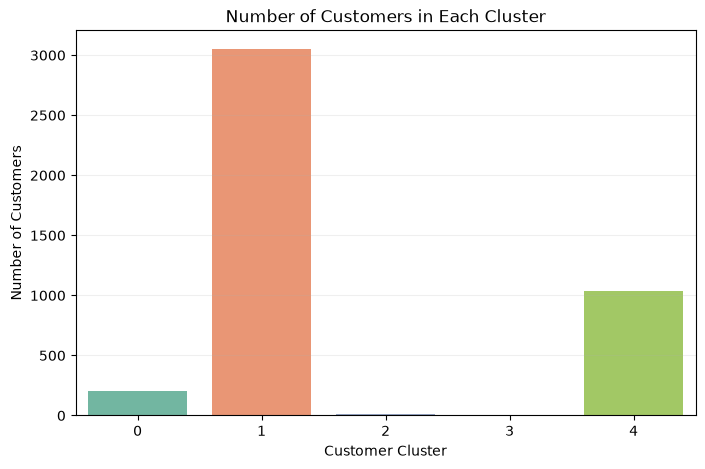

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_profile,
    x="Cluster",
    y="CustomerCount",
    hue="Cluster",
    palette="Set2",
    legend=False
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.2)

plt.show()

### Cluster Interpretation

The bar chart shows that Cluster 1 is by far the largest customer segment, containing 3,053 customers. Cluster 4 is the second-largest segment with 1,038 customers, while Cluster 0 contains 208 customers.

Clusters 2 and 3 contain only 10 and 3 customers, respectively. This confirms that these two clusters represent very small groups of customers with unusually high purchasing frequency and monetary value, rather than the typical customer behaviour in the dataset.

The distribution shows that most customers belong to the regular/developing or inactive/at-risk segments, while the highly valuable customer segments represent much smaller portions of the customer base.

### Insights and Recommended Marketing Actions

The customer segmentation analysis identified five distinct customer groups based on Recency, Frequency, and Monetary value. Each segment shows different purchasing behaviours and therefore requires a different marketing approach.

Cluster 0 – High-Value Active Customers

These 208 customers purchase frequently, have purchased recently, and have a high total monetary value.

Recommended marketing action:
Reward these customers with loyalty programmes, exclusive offers, early access to new products, and personalised recommendations to encourage continued purchases and strengthen customer loyalty.

Cluster 1 – Regular/Developing Customers

This is the largest segment, containing 3,053 customers. They have moderate recency, relatively low purchase frequency, and moderate monetary value.

Recommended marketing action:
Use personalised promotions, product recommendations, and targeted campaigns to encourage more frequent purchases and gradually increase their customer value.

Cluster 2 – Very High-Value Frequent Customers

This small group of 10 customers purchases extremely frequently, has very recent activity, and generates very high monetary value.

Recommended marketing action:
Provide VIP treatment, exclusive benefits, personalised communication, and premium loyalty rewards to retain these highly valuable customers.

Cluster 3 – Exceptional-Value Customers

This is the smallest segment, with only 3 customers. They have extremely high purchase frequency, very recent activity, and exceptionally high monetary value.

Recommended marketing action:
Prioritise customer retention through personalised relationship management, exclusive offers, premium services, and high-value loyalty incentives. Because this segment is extremely small, individualised engagement is appropriate.

Cluster 4 – Inactive/At-Risk Customers

This segment contains 1,038 customers who have not purchased for a long period, have low purchase frequency, and relatively low monetary value.

Recommended marketing action:
Launch re-engagement campaigns using personalised discounts, reminders, product recommendations, and limited-time offers to encourage these customers to return.

Overall Insight

The analysis shows that customer behaviour differs substantially across the five segments. The largest opportunity lies in Cluster 1, where increasing purchase frequency and customer value could generate substantial additional revenue because of its large customer base. At the same time, Clusters 0, 2, and 3 should be prioritised for retention because they contain highly valuable and highly engaged customers. Cluster 4 requires targeted re-engagement strategies because of its long periods of inactivity.

### Conclusion

This project applied customer segmentation techniques to identify distinct customer groups based on their purchasing behavior. After cleaning the transaction data, customer-level RFM (Recency, Frequency, and Monetary) metrics were calculated to capture how recently, how frequently, and how much customers purchased.

The RFM features were standardized and evaluated using the Elbow Method and Silhouette Analysis to determine an appropriate number of clusters. K-Means clustering with five clusters was selected, achieving a silhouette score of 0.6140, indicating reasonably well-separated and meaningful customer segments.

The resulting clusters revealed differences in customer purchasing behavior, allowing customers to be grouped into segments with distinct characteristics. These insights can support more targeted marketing strategies, such as customer retention, personalized promotions, re-engagement campaigns, and strategies for high-value customers.

It is important to note that some clusters contain very few customers, particularly Clusters 2 and 3. Their characteristics should therefore be interpreted cautiously and validated with additional data before making broad business decisions.

Overall, the analysis demonstrates how RFM analysis and K-Means clustering can transform transactional data into actionable customer insights and support more data-driven marketing decisions.